# 2. EKSTRAKSI KATA KUNCI DENGAN N-GRAM

**Ekstraksi Kata Kunci dengan N-Gram dan IndoBERT untuk Rekomendasi Wisata Bogor**

---

N-gram digunakan untuk mengekstrak kata kunci:
- **Unigram (n=1)**: Kata tunggal
- **Bigram (n=2)**: Dua kata berurutan
- **Trigram (n=3)**: Tiga kata berurutan

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = './data/'
print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# Load preprocessed data
df = pd.read_csv(f'{DATA_PATH}data_preprocessed.csv')

# Handle NaN values - replace with empty string
df['deskripsi_clean'] = df['deskripsi_clean'].fillna('').astype(str)

info = pd.DataFrame({'Keterangan': ['Total Data', 'Kolom'], 'Nilai': [len(df), str(list(df.columns))]})
print("TABEL: DATA DIMUAT")
display(info)

TABEL: DATA DIMUAT


,Keterangan,Nilai
0,Total Data,296
1,Kolom,"['nama', 'kategori', 'url', 'url_gambar', 'lik..."


## 2.1 Ekstraksi N-gram

In [3]:
def extract_ngrams(text, n):
    # Handle NaN/float/None
    if not isinstance(text, str) or pd.isna(text):
        return []
    text = str(text).strip()
    if not text:
        return []
    words = text.split()
    if len(words) < n:
        return []
    return [' '.join(words[i:i+n]) for i in range(len(words)-n+1)]

def get_top_ngrams(texts, n, top_k=10):
    all_ngrams = []
    for text in texts:
        all_ngrams.extend(extract_ngrams(text, n))
    return Counter(all_ngrams).most_common(top_k)

In [4]:
# Ekstrak global n-grams
texts = df['deskripsi_clean'].tolist()

top_unigrams = get_top_ngrams(texts, 1, 15)
top_bigrams = get_top_ngrams(texts, 2, 15)
top_trigrams = get_top_ngrams(texts, 3, 15)

# Buat tabel n-grams
ngram_table = pd.DataFrame({
    'Unigram': [f"{w} ({c})" for w, c in top_unigrams],
    'Bigram': [f"{w} ({c})" for w, c in top_bigrams],
    'Trigram': [f"{w} ({c})" for w, c in top_trigrams]
})
ngram_table.index = range(1, len(ngram_table)+1)
ngram_table.index.name = 'Rank'

print("TABEL: TOP 15 N-GRAMS (dengan frekuensi)")
display(ngram_table)

TABEL: TOP 15 N-GRAMS (dengan frekuensi)


,Unigram,Bigram,Trigram
Rank,,,
1,yang (2150),jawa barat (313),bogor jawa barat (291)
2,di (1360),article categories (295),jawa barat fasilitas (142)
3,dan (1251),article tags (292),kabupaten bogor jawa (112)
4,bogor (870),bogor jawa (291),beberapa fasilitas yang (85)
5,ini (823),tiket masuk (275),sumber article tags (83)
6,dengan (795),kabupaten bogor (253),rp jam operasional (81)
7,rp (682),air terjun (236),fasilitas yang tersedia (74)
8,untuk (647),jam operasional (232),fasilitas beberapa fasilitas (70)
9,article (587),berada di (189),parkir roda dua (69)


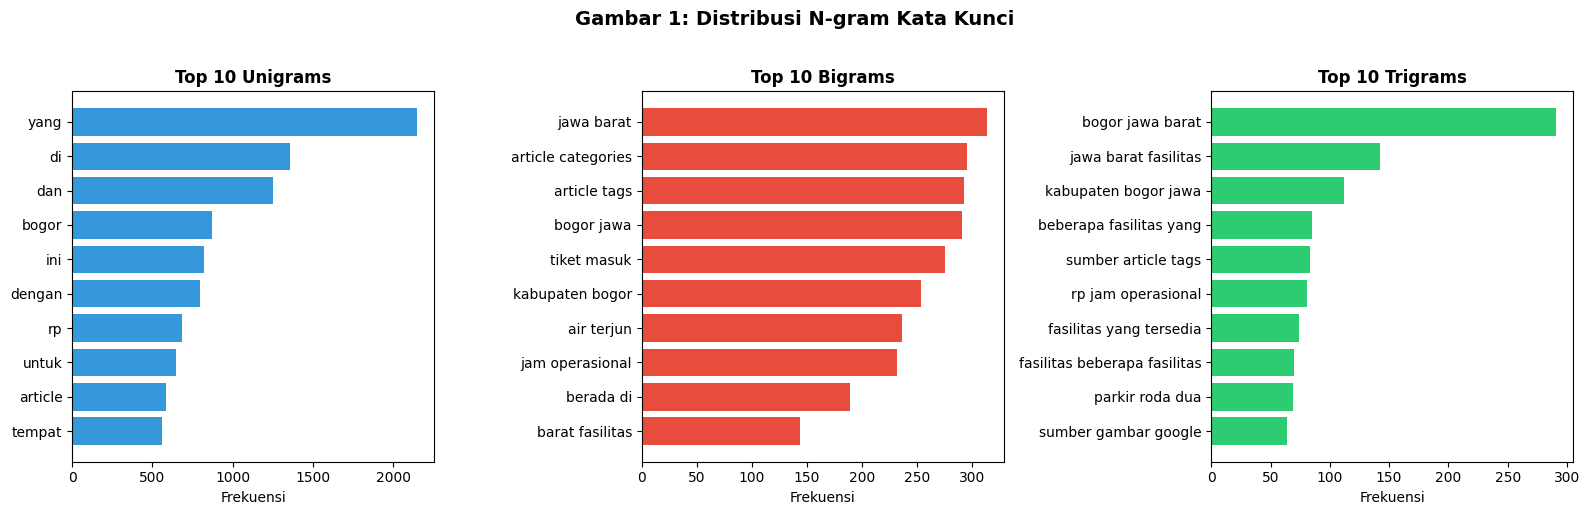

In [5]:
# Visualisasi Top N-grams
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

if top_unigrams:
    words1, counts1 = zip(*top_unigrams[:10])
    axes[0].barh(words1[::-1], counts1[::-1], color='#3498db')
axes[0].set_title('Top 10 Unigrams', fontweight='bold')
axes[0].set_xlabel('Frekuensi')

if top_bigrams:
    words2, counts2 = zip(*top_bigrams[:10])
    axes[1].barh(words2[::-1], counts2[::-1], color='#e74c3c')
axes[1].set_title('Top 10 Bigrams', fontweight='bold')
axes[1].set_xlabel('Frekuensi')

if top_trigrams:
    words3, counts3 = zip(*top_trigrams[:10])
    axes[2].barh(words3[::-1], counts3[::-1], color='#2ecc71')
axes[2].set_title('Top 10 Trigrams', fontweight='bold')
axes[2].set_xlabel('Frekuensi')

plt.suptitle('Gambar 1: Distribusi N-gram Kata Kunci', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PATH}ngram_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 Ekstraksi Kata Kunci per Wisata

In [6]:
def extract_keywords_per_item(text, top_k=5):
    unigrams = extract_ngrams(text, 1)
    bigrams = extract_ngrams(text, 2)
    trigrams = extract_ngrams(text, 3)
    
    top_uni = [w for w, c in Counter(unigrams).most_common(top_k)]
    top_bi = [w for w, c in Counter(bigrams).most_common(top_k)]
    top_tri = [w for w, c in Counter(trigrams).most_common(top_k)]
    
    return {'unigrams': top_uni, 'bigrams': top_bi, 'trigrams': top_tri}

df['keywords'] = df['deskripsi_clean'].apply(extract_keywords_per_item)
df['unigrams'] = df['keywords'].apply(lambda x: ', '.join(x['unigrams'][:3]) if x['unigrams'] else '')
df['bigrams'] = df['keywords'].apply(lambda x: ', '.join(x['bigrams'][:3]) if x['bigrams'] else '')
df['trigrams'] = df['keywords'].apply(lambda x: ', '.join(x['trigrams'][:2]) if x['trigrams'] else '')

In [7]:
# TABEL: Kata kunci per wisata
keywords_table = df[['nama', 'kategori', 'unigrams', 'bigrams', 'trigrams']].head(10).copy()
keywords_table.columns = ['Nama Wisata', 'Kategori', 'Top Unigrams', 'Top Bigrams', 'Top Trigrams']
keywords_table.index = range(1, len(keywords_table)+1)

print("TABEL: KATA KUNCI N-GRAM PER WISATA (10 Sampel)")
display(keywords_table)

TABEL: KATA KUNCI N-GRAM PER WISATA (10 Sampel)


,Nama Wisata,Kategori,Top Unigrams,Top Bigrams,Top Trigrams
1,Curug Ciampea,Arena,"curug, yang, ciampea","curug ciampea, ciampea bogor, air terjun","curug ciampea bogor, wisata curug ciampea"
2,Bukit Cirimpak,Arena,"yang, cirimpak, bukit","bukit cirimpak, camping ground, salah satu","salah satu camping, satu camping ground"
3,Lembah Tepus,Arena,"di, yang, dan","lembah tepus, air terjun, tepus adalah","lembah tepus adalah, air terjun bertingkat"
4,Sun Water Park Kahuripan,Arena,"kolam, di, renang","kolam renang, water park, sun water","sun water park, water park kahuripan"
5,Lembah Pinus Camp & Café,Arena,"di, blok, pinus","lembah pinus, pinus camp, camp cafe","lembah pinus camp, pinus camp cafe"
6,Bukit Alas Bandawasa,Arena,"bukit, yang, ini","bukit alas, alas bandawasa, kaki gunung","bukit alas bandawasa, kaki gunung salak"
7,Nirwana Golden Park,Arena,"kolam, renang, yang","kolam renang, nirwana golden, golden park","nirwana golden park, kolam renang nirwana"
8,Rumah Ibu Waterboom,Arena,"waterboom, yang, ke","rumah ibu, masuk ke, kecamatan bojonggede","bojonggede kabupaten bogor, rumah ibu waterboom"
9,Gumati Waterpark,Arena,"yang, di, kolam","yang bisa, di kolam, gumati waterpark","yang bisa di, tidak boleh membawa"
10,Boash Waterpark,Arena,"kolam, di, bogor","kolam renang, boash waterpark, di bogor","di kolam ini, bagi orang dewasa"


## 2.3 TF-IDF Vectorization dengan N-gram

In [8]:
# TF-IDF dengan N-gram range (1,3)
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=5000,
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['deskripsi_clean'])

# Statistik N-gram
vocab = list(tfidf_vectorizer.vocabulary_.keys())
unigram_count = sum(1 for v in vocab if len(v.split()) == 1)
bigram_count = sum(1 for v in vocab if len(v.split()) == 2)
trigram_count = sum(1 for v in vocab if len(v.split()) == 3)

stats = pd.DataFrame({
    'Tipe N-gram': ['Unigram (n=1)', 'Bigram (n=2)', 'Trigram (n=3)', 'Total'],
    'Jumlah': [unigram_count, bigram_count, trigram_count, len(vocab)],
    'Persentase': [f"{unigram_count/len(vocab)*100:.1f}%" if len(vocab) > 0 else '0%', 
                   f"{bigram_count/len(vocab)*100:.1f}%" if len(vocab) > 0 else '0%', 
                   f"{trigram_count/len(vocab)*100:.1f}%" if len(vocab) > 0 else '0%', '100%']
})
print("TABEL: STATISTIK N-GRAM DALAM VOCABULARY TF-IDF")
display(stats)

TABEL: STATISTIK N-GRAM DALAM VOCABULARY TF-IDF


,Tipe N-gram,Jumlah,Persentase
0,Unigram (n=1),1829,36.6%
1,Bigram (n=2),2190,43.8%
2,Trigram (n=3),981,19.6%
3,Total,5000,100%


In [9]:
# TF-IDF Info
tfidf_info = pd.DataFrame({
    'Parameter': ['Matrix Shape', 'Vocabulary Size', 'N-gram Range', 'Max Features', 'Min DF', 'Max DF'],
    'Nilai': [str(tfidf_matrix.shape), len(vocab), '(1, 3)', 5000, 1, 0.95]
})
print("\nTABEL: PARAMETER TF-IDF VECTORIZER")
display(tfidf_info)


TABEL: PARAMETER TF-IDF VECTORIZER


,Parameter,Nilai
0,Matrix Shape,"(296, 5000)"
1,Vocabulary Size,5000
2,N-gram Range,"(1, 3)"
3,Max Features,5000
4,Min DF,1
5,Max DF,0.95


In [10]:
# Simpan hasil
import pickle

np.save(f'{DATA_PATH}tfidf_matrix.npy', tfidf_matrix.toarray())
with open(f'{DATA_PATH}tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

df[['nama', 'kategori', 'deskripsi_clean', 'unigrams', 'bigrams', 'trigrams']].to_csv(
    f'{DATA_PATH}data_with_keywords.csv', index=False, encoding='utf-8-sig'
)

files_saved = pd.DataFrame({
    'File': ['tfidf_matrix.npy', 'tfidf_vectorizer.pkl', 'data_with_keywords.csv'],
    'Deskripsi': ['TF-IDF matrix', 'Vectorizer object', 'Data dengan keywords']
})
print("TABEL: FILES SAVED")
display(files_saved)

TABEL: FILES SAVED


,File,Deskripsi
0,tfidf_matrix.npy,TF-IDF matrix
1,tfidf_vectorizer.pkl,Vectorizer object
2,data_with_keywords.csv,Data dengan keywords


In [11]:
# Summary
summary = pd.DataFrame({
    'Aspek': ['Total Wisata', 'Vocabulary Size', 'TF-IDF Matrix', 'Top Bigram'],
    'Nilai': [len(df), len(vocab), str(tfidf_matrix.shape), 
              f"'{top_bigrams[0][0]}' (freq: {top_bigrams[0][1]})" if top_bigrams else 'N/A']
})
print("\nTABEL: SUMMARY EKSTRAKSI N-GRAM")
display(summary)


TABEL: SUMMARY EKSTRAKSI N-GRAM


,Aspek,Nilai
0,Total Wisata,296
1,Vocabulary Size,5000
2,TF-IDF Matrix,"(296, 5000)"
3,Top Bigram,'jawa barat' (freq: 313)
